=== Path Check ===
  OK      S1Hand                     → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                  → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING Weak S1 (unlabeled pool)   → None
  MISSING Weak label masks           → None

Deriving image-level labels from masks (flooded = water fraction ≥ 0.01) ...
  Chips: 441  (293 flooded | 148 non-flooded)

=== Dataset Split ===
  Train     : 176  (121 flooded | 55 non-flooded)
  Val       : 89  (59 flooded | 30 non-flooded)
  Unlabeled : 176  ← 50% of train chips (labels discarded — no weak S1 folder found)
  Reference labels for unlabeled pool: 176/176  ← hidden hand-mask labels (exact)

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
λ sweep : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Total runs: 11 × 50 epochs = 550 epochs


███████████████████████████████████

100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]



════════════════════════════════════════════════════════════════════════════════════════════════════════
  ResNet-18  |  λ = 0.0  |  50 epochs
════════════════════════════════════════════════════════════════════════════════════════════════════════
 Ep │    λ │     α │     Loss │    Acc │     F1 │   Prec │    Rec │    AUC │  #Psd │ PsdAcc
────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 │  0.0 │ 0.000 │   0.4191 │ 0.7191 │ 0.7525 │ 0.9048 │ 0.6441 │ 0.8226 │   176 │ 0.7443
  2 │  0.0 │ 0.000 │   0.2125 │ 0.7528 │ 0.8070 │ 0.8364 │ 0.7797 │ 0.8525 │   176 │ 0.8409
  3 │  0.0 │ 0.000 │   0.1396 │ 0.7303 │ 0.8033 │ 0.7778 │ 0.8305 │ 0.8452 │   176 │ 0.8239
  4 │  0.0 │ 0.000 │   0.0562 │ 0.7528 │ 0.8254 │ 0.7761 │ 0.8814 │ 0.8401 │   176 │ 0.8068
  5 │  0.0 │ 0.000 │   0.0729 │ 0.8202 │ 0.8730 │ 0.8209 │ 0.9322 │ 0.8616 │   176 │ 0.8125
  6 │  0.0 │ 0.000 │   0.0447 │ 0.7865 │ 0.8403 │ 0.8333 │ 0.8475 │ 0.8593 │   176 │ 0.8352
  

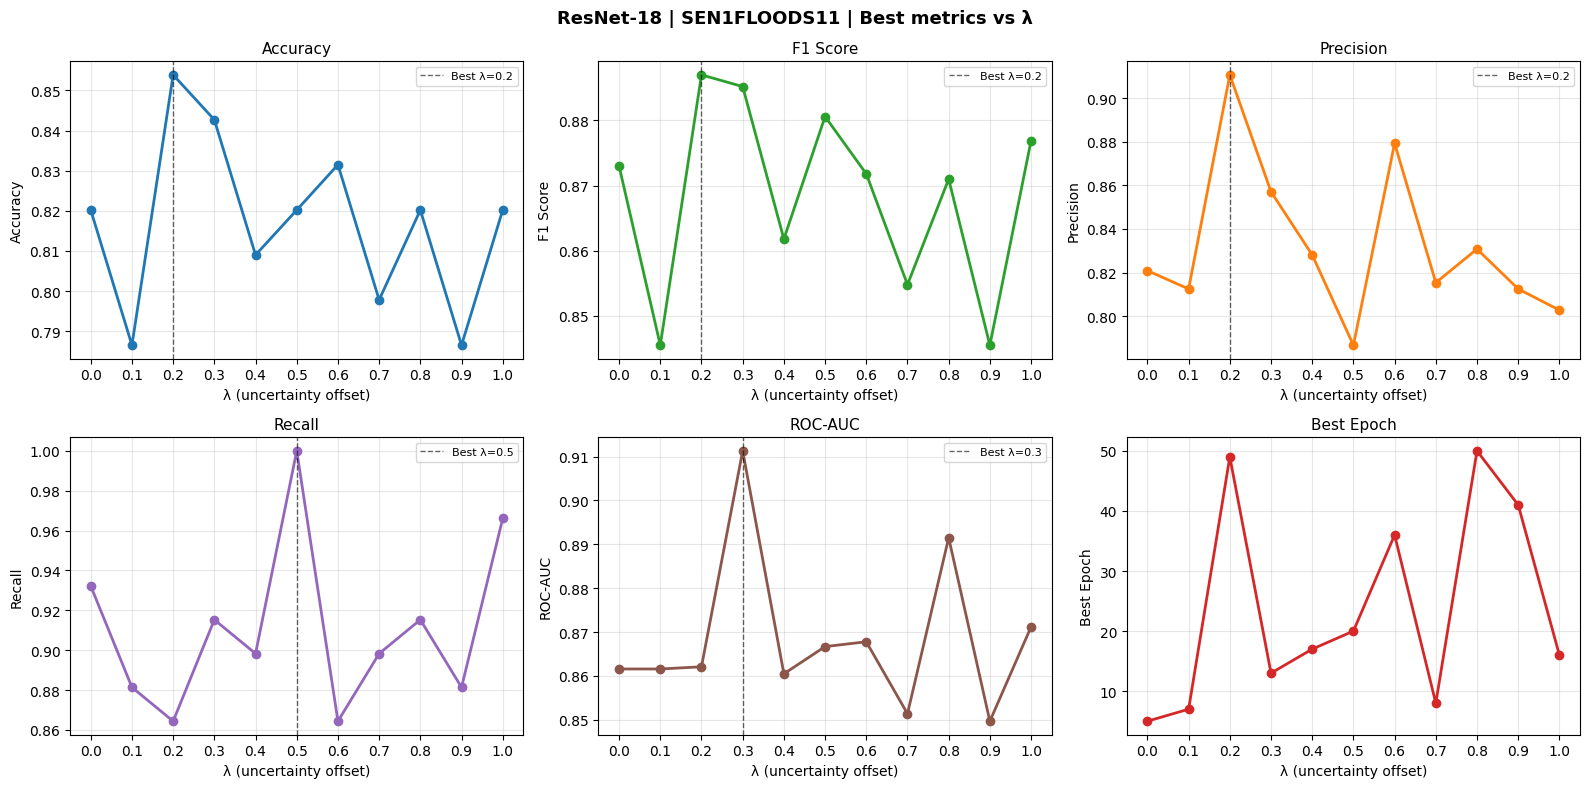

Saved → resnet18_sen1floods11_metrics_vs_lambda.png


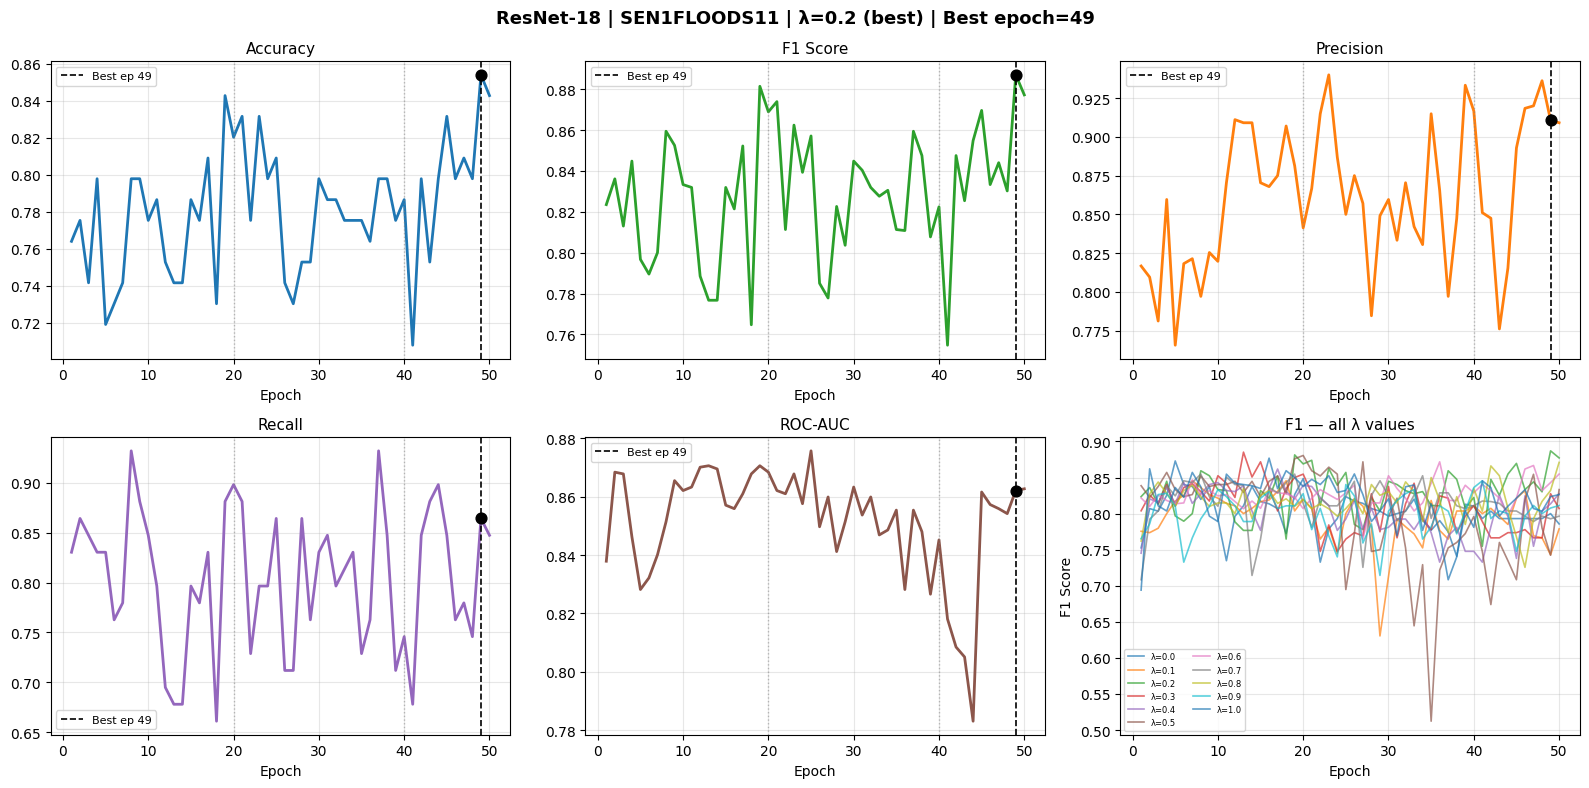

Saved → resnet18_sen1floods11_training_curves.png


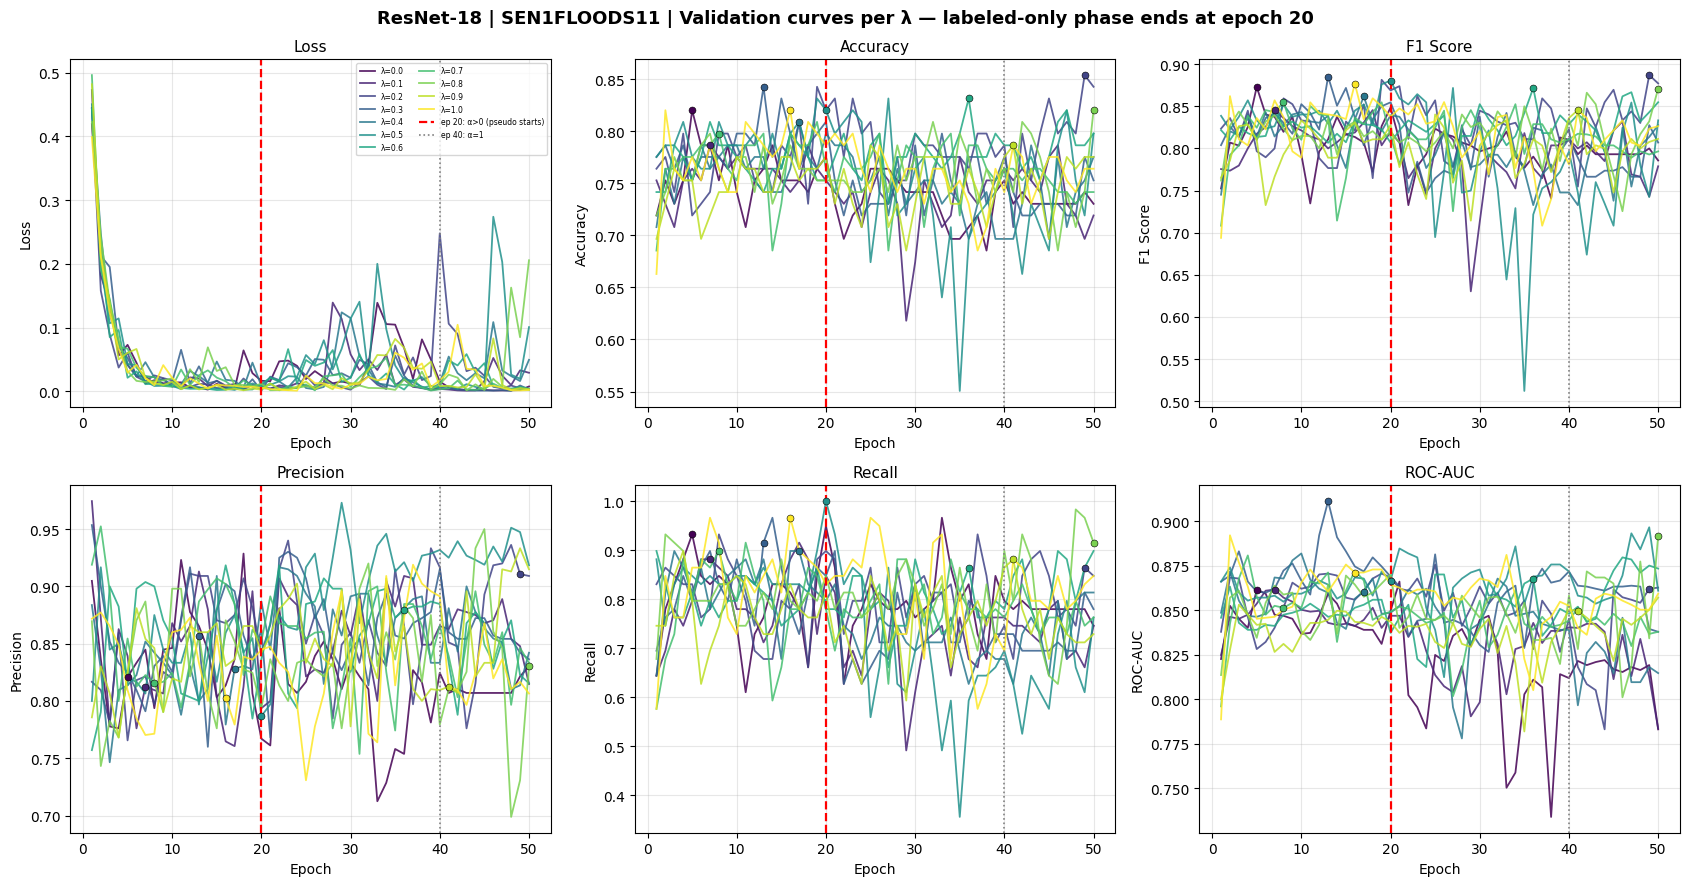

Saved → resnet18_sen1floods11_valcurves_alpha20.png


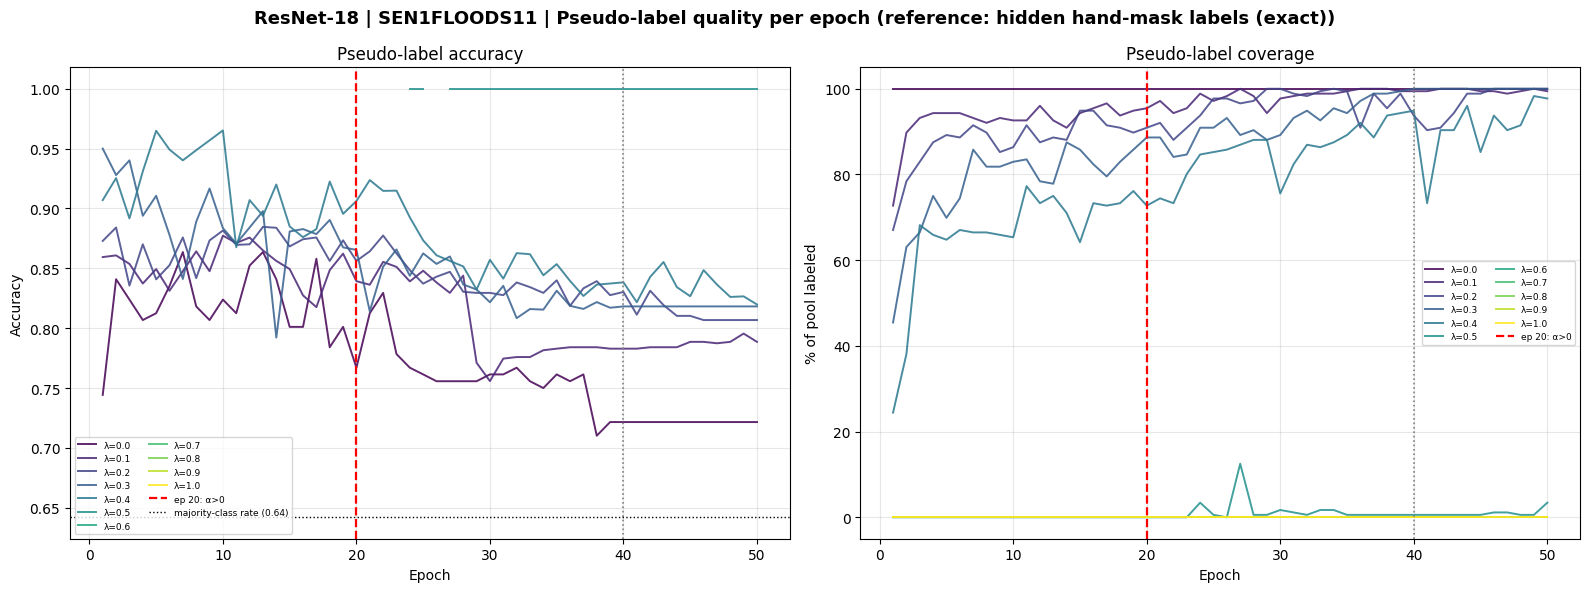

Saved → resnet18_sen1floods11_pseudolabel_quality.png


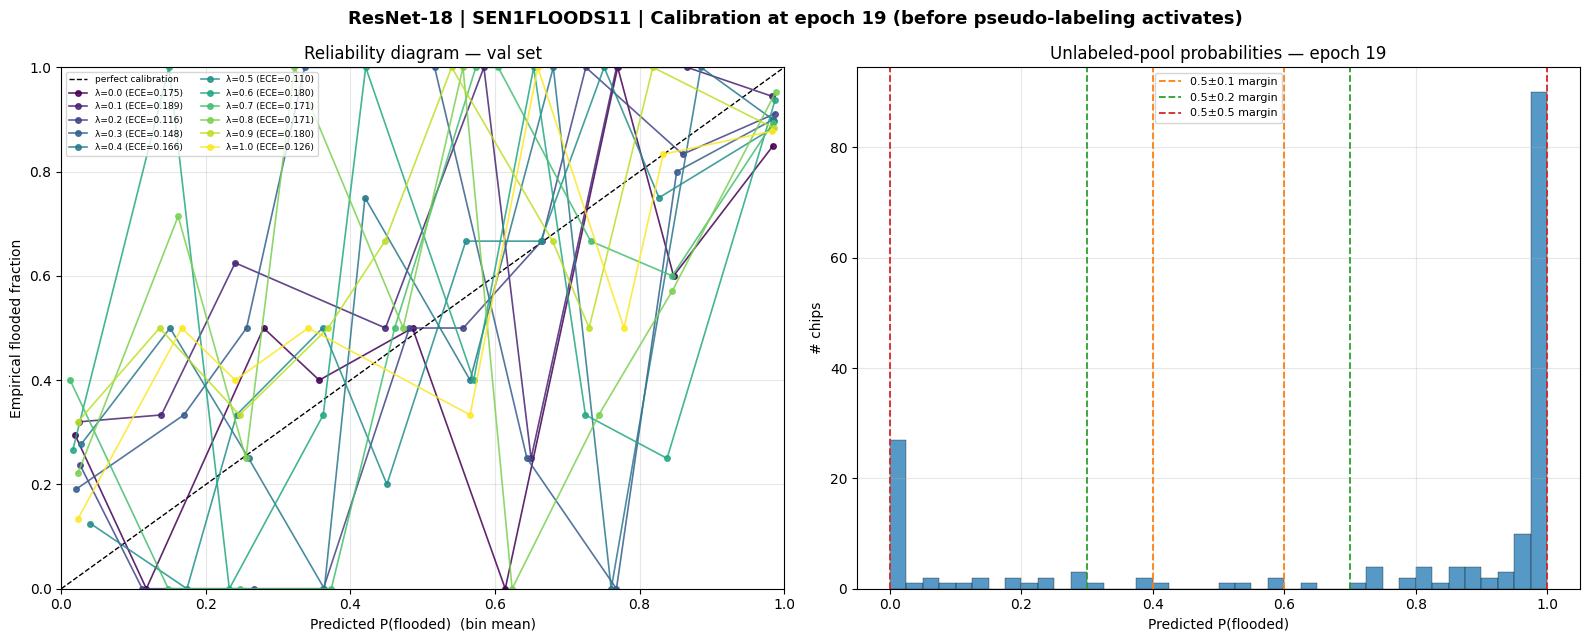

Saved → resnet18_sen1floods11_calibration_ep19.png

✓ All done.


In [1]:
import os, copy, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── 1. PATHS — auto-detect the dataset layout ──────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download("smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    """Walk directories only (cheap) and return the first match by name."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR        = find_dir(ROOT, "S1Hand")
LABEL_DIR     = find_dir(ROOT, "LabelHand")
WEAK_DIR      = find_dir(ROOT, "S1Weak")            # weakly-labeled S1 chips
WEAK_LBL_DIR  = (find_dir(ROOT, "S1OtsuLabelWeak")  # weak reference masks
                 or find_dir(ROOT, "S2IndexLabelWeak"))

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("Weak S1 (unlabeled pool)", WEAK_DIR),
                ("Weak label masks", WEAK_LBL_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<26} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None, \
    "Could not locate S1Hand / LabelHand folders — check dataset root."

# ── 2. Derive image-level labels from pixel masks ──────────────────────
FLOOD_THRESHOLD    = 0.01   # chip = flooded if ≥1% of valid pixels are water
UNLABELED_FRACTION = 0.50   # fallback only (when no weak S1 folder exists)
MAX_UNLABELED      = 1500   # cap unlabeled pool (RAM guard, ≈ FloodNet size)
CAL_EPOCH          = 19     # calibration snapshot (last α=0 stretch)

def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print("\nDeriving image-level labels from masks "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")

all_samples = []                      # (s1_path, label)
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:                    # chip is entirely no-data
        continue
    all_samples.append((str(s1_path), int(wf >= FLOOD_THRESHOLD)))

flooded_s    = [s for s in all_samples if s[1] == 1]
nonflooded_s = [s for s in all_samples if s[1] == 0]
print(f"  Chips: {len(all_samples)}  "
      f"({len(flooded_s)} flooded | {len(nonflooded_s)} non-flooded)")

# ── 3. 80/20 labeled split (same as FloodNet run) ─────────────────────
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

TRAIN_SAMPLES = f_train + nf_train
VAL_SAMPLES   = f_val   + nf_val

# ── 4. Unlabeled pool ─────────────────────────────────────────────────
if WEAK_DIR is not None:
    UNLABELED_PATHS = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(UNLABELED_PATHS)
    UNLABELED_PATHS = UNLABELED_PATHS[:MAX_UNLABELED]
    unl_source = f"weakly-labeled S1 chips ({WEAK_DIR.name})"
else:
    # Standard SSL simulation: hide the labels of part of the train split
    random.shuffle(TRAIN_SAMPLES)
    cut             = int((1 - UNLABELED_FRACTION) * len(TRAIN_SAMPLES))
    UNLABELED_PATHS = [p for p, _ in TRAIN_SAMPLES[cut:]]
    # NEW: remember the hidden true labels for pseudo-label accuracy
    HIDDEN_TRUE     = {p: l for p, l in TRAIN_SAMPLES[cut:]}
    TRAIN_SAMPLES   = TRAIN_SAMPLES[:cut]
    unl_source = (f"{UNLABELED_FRACTION:.0%} of train chips "
                  "(labels discarded — no weak S1 folder found)")

# ── 4b. NEW — reference labels for the unlabeled pool ──────────────────
#  Needed to measure pseudo-label ACCURACY. Sources:
#   • fallback pool → the hidden true labels (exact, from hand masks)
#   • weak pool     → labels derived from the weak masks (approximate)
UNLABELED_TRUE = {}
if WEAK_DIR is None:
    UNLABELED_TRUE = HIDDEN_TRUE
    ref_source = "hidden hand-mask labels (exact)"
elif WEAK_LBL_DIR is not None:
    weak_suffix = f"_{WEAK_LBL_DIR.name}.tif"
    s1w_suffix  = f"_{WEAK_DIR.name}.tif"
    print(f"\nDeriving reference labels for the unlabeled pool "
          f"from {WEAK_LBL_DIR.name} masks ...")
    for p in UNLABELED_PATHS:
        stem = Path(p).name.replace(s1w_suffix, "")
        wm   = WEAK_LBL_DIR / f"{stem}{weak_suffix}"
        if not wm.exists():
            continue
        wf = water_fraction(wm)
        if wf is not None:
            UNLABELED_TRUE[p] = int(wf >= FLOOD_THRESHOLD)
    ref_source = f"weak masks ({WEAK_LBL_DIR.name}, approximate)"
else:
    ref_source = "NONE — pseudo-label accuracy will be NaN"

n_f_tr  = sum(1 for _, l in TRAIN_SAMPLES if l == 1)
n_nf_tr = sum(1 for _, l in TRAIN_SAMPLES if l == 0)
n_tr    = len(TRAIN_SAMPLES)

print(f"\n=== Dataset Split ===")
print(f"  Train     : {n_tr}  ({n_f_tr} flooded | {n_nf_tr} non-flooded)")
print(f"  Val       : {len(VAL_SAMPLES)}  "
      f"({sum(1 for _, l in VAL_SAMPLES if l == 1)} flooded | "
      f"{sum(1 for _, l in VAL_SAMPLES if l == 0)} non-flooded)")
print(f"  Unlabeled : {len(UNLABELED_PATHS)}  ← {unl_source}")
print(f"  Reference labels for unlabeled pool: {len(UNLABELED_TRUE)}"
      f"/{len(UNLABELED_PATHS)}  ← {ref_source}")

# ── 5. Fixed hyper-parameters (identical to FloodNet run) ─────────────
IMG_SIZE  = 224
BATCH     = 16
LR        = 1e-4
E         = 50
E_ia      = 20       # labeled-only phase ends   (E_i^a)
E_fa      = 40       # alpha ramp ends            (E_f^a)
a_i, a_f  = 0.0, 1.0
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# λ sweep: 0.0, 0.1, 0.2, ... 1.0  (11 values)
LAMBDA_VALUES = [round(x * 0.1, 1) for x in range(11)]

print(f"\nDevice  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"λ sweep : {LAMBDA_VALUES}")
print(f"Total runs: {len(LAMBDA_VALUES)} × {E} epochs = {len(LAMBDA_VALUES)*E} epochs")

# ── 6. Alpha schedule (Algorithm 1, lines 2-7) ────────────────────────
def get_alpha(ep):
    if ep < E_ia: return a_i
    if ep < E_fa: return ((a_f-a_i)/(E_fa-E_ia))*(ep-E_ia)+a_i
    return a_f

# ── 7. SAR chip loading → 3-channel tensor ────────────────────────────
DB_MIN, DB_MAX = -50.0, 1.0     # typical Sentinel-1 backscatter range (dB)
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    """2-band SAR GeoTIFF → normalized 3×224×224 float tensor."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)          # (2, H, W)
    arr = np.nan_to_num(arr, nan=DB_MIN)             # no-data → floor
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)         # dB → [0, 1]
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])        # (3, H, W)
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

# ── 8. Dataset classes ────────────────────────────────────────────────
class LabeledDS(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return load_s1_tensor(path), torch.tensor(lbl, dtype=torch.float32)

class UnlabeledDS(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return load_s1_tensor(self.paths[i]), self.paths[i]

# ── 9. Fixed dataloaders (same split for all λ runs) ──────────────────
cw      = [n_tr/(2*n_nf_tr), n_tr/(2*n_f_tr)]
sw      = [cw[int(s[1])] for s in TRAIN_SAMPLES]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

train_ds  = LabeledDS(TRAIN_SAMPLES)
val_ds    = LabeledDS(VAL_SAMPLES)
unl_ds    = UnlabeledDS(UNLABELED_PATHS)

train_ldr = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                       num_workers=2, pin_memory=True)
val_ldr   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                       num_workers=2, pin_memory=True)
unl_ldr   = DataLoader(unl_ds,   batch_size=BATCH, shuffle=False,
                       num_workers=2, pin_memory=True)

# ── 10. Build ResNet-18 ───────────────────────────────────────────────
def build_resnet18():
    """
    ResNet-18 with pretrained ImageNet weights.
    Replace final FC: 512 → 1 (binary sigmoid output).
    """
    m = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 1)   # 512 → 1
    return m

# ── 11. Evaluation ────────────────────────────────────────────────────
def evaluate(model, loader, return_probs=False):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    if return_probs:
        return (acc, f1, prec, rec, roc), np.array(probs_all), np.array(lbls_all)
    return acc, f1, prec, rec, roc

# ── 11b. NEW — calibration helpers (reliability bins + ECE) ────────────
def reliability_bins(probs, labels, n_bins=10):
    """Bin predicted P(flooded); per bin: mean confidence, empirical
    positive rate, count. ECE = count-weighted |freq − conf|."""
    probs, labels = np.asarray(probs), np.asarray(labels)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows  = []
    ece   = 0.0
    for b in range(n_bins):
        m = (probs >= edges[b]) & (probs < edges[b+1] if b < n_bins-1
                                   else probs <= edges[b+1])
        if not m.any():
            rows.append((edges[b], edges[b+1], np.nan, np.nan, 0))
            continue
        conf = probs[m].mean()
        freq = labels[m].mean()
        rows.append((edges[b], edges[b+1], conf, freq, int(m.sum())))
        ece += (m.sum() / len(probs)) * abs(freq - conf)
    return rows, ece

# ── 12. One full training run for a given λ ───────────────────────────
def train_one_lambda(lam):
    """Train ResNet-18 for E epochs with uncertainty offset = lam.
    NEW: every epoch the unlabeled pool is scored once; the would-be
    pseudo-labels are compared against the reference labels, and at
    epoch CAL_EPOCH the raw probabilities are snapshotted for the
    calibration analysis. The parameter updates are UNCHANGED."""
    model     = build_resnet18().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()

    history    = []
    best_f1    = -1
    best_epoch = -1
    best_row   = {}
    best_state = None
    cal_snap   = None      # calibration snapshot at CAL_EPOCH

    print(f"\n{'═'*104}")
    print(f"  ResNet-18  |  λ = {lam:.1f}  |  {E} epochs")
    print(f"{'═'*104}")
    print(f"{'Ep':>3} │ {'λ':>4} │ {'α':>5} │ {'Loss':>8} │ "
          f"{'Acc':>6} │ {'F1':>6} │ {'Prec':>6} │ {'Rec':>6} │ {'AUC':>6} │ "
          f"{'#Psd':>5} │ {'PsdAcc':>6}")
    print(f"{'─'*104}")

    for ep in range(E):
        model.train()
        alpha = get_alpha(ep)
        total_loss, n_batches = 0.0, 0

        # Phase A — labeled pass
        for imgs, lbls in train_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1

        # Phase B — score unlabeled pool (Algorithm 1 lines 8-15)
        # NEW: this pass now runs EVERY epoch so pseudo-label accuracy
        # can be tracked even while α=0 (when Phase C is skipped and
        # the pseudo-labels are hypothetical). Training is unaffected.
        model.eval()
        p_imgs, p_lbls = [], []
        u_paths, u_probs = [], []
        with torch.no_grad():
            for imgs, paths in unl_ldr:
                imgs  = imgs.to(DEVICE)
                probs = torch.sigmoid(model(imgs).squeeze(1)).cpu().numpy()
                for i, pv in enumerate(probs):
                    u_paths.append(paths[i])
                    u_probs.append(float(pv))
                    if alpha > 0:
                        if pv <= 0.5 - lam:             # confident non-flooded
                            p_imgs.append(imgs[i].cpu())
                            p_lbls.append(torch.tensor(0.0))
                        elif pv >= 0.5 + lam:           # confident flooded
                            p_imgs.append(imgs[i].cpu())
                            p_lbls.append(torch.tensor(1.0))
                        # else: uncertain margin → ignored

        # NEW — pseudo-label stats vs reference labels (per epoch)
        n_pseudo, n_known, n_correct = 0, 0, 0
        for pth, pv in zip(u_paths, u_probs):
            if pv <= 0.5 - lam:   pl = 0
            elif pv >= 0.5 + lam: pl = 1
            else:                 continue
            n_pseudo += 1
            if pth in UNLABELED_TRUE:
                n_known   += 1
                n_correct += int(UNLABELED_TRUE[pth] == pl)
        pseudo_acc = n_correct / n_known if n_known else float("nan")

        # Phase C — fine-tune on pseudo-labeled (unchanged)
        if alpha > 0 and p_imgs:
            model.train()
            for s in range(0, len(p_imgs), BATCH):
                pi = torch.stack(p_imgs[s:s+BATCH]).to(DEVICE)
                pl = torch.stack(p_lbls[s:s+BATCH]).to(DEVICE)
                optimizer.zero_grad()
                loss_u = alpha * criterion(model(pi).squeeze(1), pl)
                loss_u.backward(); optimizer.step()
                total_loss += loss_u.item(); n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)

        # NEW — calibration snapshot at CAL_EPOCH (val + unlabeled probs)
        if ep + 1 == CAL_EPOCH:
            (acc, f1, prec, rec, roc), vp, vl = evaluate(
                model, val_ldr, return_probs=True)
            cal_snap = dict(val_probs=vp, val_lbls=vl,
                            unl_paths=list(u_paths),
                            unl_probs=list(u_probs))
        else:
            acc, f1, prec, rec, roc = evaluate(model, val_ldr)

        row = dict(lambda_=lam, epoch=ep+1, alpha=round(alpha,4),
                   loss=round(avg_loss,4), accuracy=round(acc,4),
                   f1=round(f1,4), precision=round(prec,4),
                   recall=round(rec,4), roc_auc=round(roc,4),
                   n_pseudo=n_pseudo, pseudo_known=n_known,
                   pseudo_acc=round(pseudo_acc,4) if n_known else float("nan"))
        history.append(row)

        print(f"{ep+1:3d} │ {lam:4.1f} │ {alpha:5.3f} │ {avg_loss:8.4f} │ "
              f"{acc:6.4f} │ {f1:6.4f} │ {prec:6.4f} │ {rec:6.4f} │ "
              f"{roc:6.4f} │ {n_pseudo:5d} │ {pseudo_acc:6.4f}")

        if f1 > best_f1:
            best_f1=f1; best_epoch=ep+1
            best_row=row.copy()
            best_state=copy.deepcopy(model.state_dict())

    print(f"{'─'*104}")
    print(f"  ★ Best epoch {best_epoch}  |  "
          f"Acc={best_row['accuracy']:.4f}  F1={best_row['f1']:.4f}  "
          f"Prec={best_row['precision']:.4f}  Rec={best_row['recall']:.4f}  "
          f"AUC={best_row['roc_auc']:.4f}")

    return history, best_row, best_state, cal_snap

# ── 13. λ SWEEP ───────────────────────────────────────────────────────
print("\n\n" + "█"*88)
print("  STARTING λ SWEEP  —  ResNet-18  |  SEN1FLOODS11  (instrumented)")
print("█"*88)

all_history   = []   # every epoch of every λ
summary_rows  = []   # one best row per λ
best_states   = {}   # λ → state_dict
cal_snaps     = {}   # λ → calibration snapshot at CAL_EPOCH

for lam in LAMBDA_VALUES:
    hist, best_row, best_state, cal_snap = train_one_lambda(lam)
    all_history.extend(hist)
    summary_rows.append(best_row)
    best_states[lam] = best_state
    cal_snaps[lam]   = cal_snap

# ── 14. Summary table ─────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("lambda_").reset_index(drop=True)

print("\n\n" + "═"*88)
print("  FINAL SUMMARY — Best results per λ value")
print("═"*88)
print(f"{'λ':>5} │ {'Epoch':>5} │ {'Acc':>6} │ {'F1':>6} │ "
      f"{'Prec':>6} │ {'Rec':>6} │ {'AUC':>6}")
print("─"*88)
for _, r in summary_df.iterrows():
    marker = "  ◄ BEST" if r["f1"] == summary_df["f1"].max() else ""
    print(f"{r['lambda_']:>5.1f} │ {r['epoch']:>5} │ {r['accuracy']:>6.4f} │ "
          f"{r['f1']:>6.4f} │ {r['precision']:>6.4f} │ "
          f"{r['recall']:>6.4f} │ {r['roc_auc']:>6.4f}{marker}")
print("═"*88)

best_lambda  = summary_df.loc[summary_df["f1"].idxmax(), "lambda_"]
best_overall = summary_df.loc[summary_df["f1"].idxmax()]
print(f"\n  Best λ overall : {best_lambda}")
print(f"  Best Accuracy  : {best_overall['accuracy']:.4f}")
print(f"  Best F1        : {best_overall['f1']:.4f}")
print(f"  Best Precision : {best_overall['precision']:.4f}")
print(f"  Best Recall    : {best_overall['recall']:.4f}")
print(f"  Best ROC-AUC   : {best_overall['roc_auc']:.4f}")
print(f"  Best Epoch     : {int(best_overall['epoch'])}")

# ── 15. Save ──────────────────────────────────────────────────────────
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
all_df = pd.DataFrame(all_history)
all_df.to_csv(f"{OUT}/resnet18_sen1floods11_all_history.csv", index=False)
summary_df.to_csv(f"{OUT}/resnet18_sen1floods11_lambda_summary.csv", index=False)
torch.save(best_states[best_lambda],
           f"{OUT}/resnet18_sen1floods11_best.pth")
print(f"\nSaved → resnet18_sen1floods11_all_history.csv "
      f"(now incl. n_pseudo / pseudo_acc columns)")
print(f"Saved → resnet18_sen1floods11_lambda_summary.csv")
print(f"Saved → resnet18_sen1floods11_best.pth  (λ={best_lambda})")

# NEW — raw calibration snapshot at CAL_EPOCH → CSV (for re-plotting)
cal_rows = []
for lam, snap in cal_snaps.items():
    if snap is None:
        continue
    for pr, lb in zip(snap["val_probs"], snap["val_lbls"]):
        cal_rows.append(dict(lambda_=lam, set="val",
                             prob=float(pr), true=int(lb)))
    for pth, pr in zip(snap["unl_paths"], snap["unl_probs"]):
        cal_rows.append(dict(lambda_=lam, set="unlabeled", prob=float(pr),
                             true=UNLABELED_TRUE.get(pth, -1)))
cal_df = pd.DataFrame(cal_rows)
cal_df.to_csv(f"{OUT}/resnet18_sen1floods11_calibration_ep{CAL_EPOCH}.csv",
              index=False)
print(f"Saved → resnet18_sen1floods11_calibration_ep{CAL_EPOCH}.csv")

# ── 16. Plot 1 — metrics vs λ (summary) ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("ResNet-18 | SEN1FLOODS11 | Best metrics vs λ",
             fontsize=13, fontweight="bold")
pairs = [("accuracy","Accuracy","tab:blue"),
         ("f1","F1 Score","tab:green"),
         ("precision","Precision","tab:orange"),
         ("recall","Recall","tab:purple"),
         ("roc_auc","ROC-AUC","tab:brown"),
         ("epoch","Best Epoch","tab:red")]

for ax, (col, title, color) in zip(axes.flat, pairs):
    ax.plot(summary_df["lambda_"], summary_df[col],
            color=color, linewidth=2, marker="o", markersize=6)
    best_val = summary_df[col].max() if col != "epoch" else None
    if best_val is not None:
        best_lam = summary_df.loc[summary_df[col].idxmax(), "lambda_"]
        ax.axvline(best_lam, color="black", linestyle="--",
                   linewidth=1, alpha=0.6, label=f"Best λ={best_lam}")
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("λ (uncertainty offset)")
    ax.set_ylabel(title)
    ax.set_xticks(LAMBDA_VALUES)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/resnet18_sen1floods11_metrics_vs_lambda.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → resnet18_sen1floods11_metrics_vs_lambda.png")

# ── 17. Plot 2 — training curves for best λ ───────────────────────────
best_hist = all_df[all_df["lambda_"] == best_lambda].reset_index(drop=True)
best_ep   = int(best_overall["epoch"])

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
fig2.suptitle(
    f"ResNet-18 | SEN1FLOODS11 | λ={best_lambda} (best) | Best epoch={best_ep}",
    fontsize=13, fontweight="bold"
)
for ax, (col, title, color) in zip(axes2.flat, pairs[:-1]):
    ax.plot(best_hist["epoch"], best_hist[col], color=color, linewidth=2)
    ax.axvline(best_ep, color="black", linestyle="--",
               linewidth=1.2, label=f"Best ep {best_ep}")
    bv = best_hist.loc[best_hist["epoch"]==best_ep, col].values[0]
    ax.scatter([best_ep],[bv], color="black", zorder=5, s=60)
    ax.axvline(E_ia, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.axvline(E_fa, color="gray", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Last panel: all λ F1 curves together
ax_last = axes2.flat[-1]
for lam in LAMBDA_VALUES:
    sub = all_df[all_df["lambda_"]==lam]
    ax_last.plot(sub["epoch"], sub["f1"],
                 linewidth=1.2, alpha=0.7, label=f"λ={lam}")
ax_last.set_title("F1 — all λ values", fontsize=11)
ax_last.set_xlabel("Epoch")
ax_last.set_ylabel("F1 Score")
ax_last.legend(fontsize=6, ncol=2)
ax_last.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT}/resnet18_sen1floods11_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → resnet18_sen1floods11_training_curves.png")

# ══ NEW PLOTS (team-lead request) ══════════════════════════════════════

# ── 18. Plot 3 — val curves for ALL λ, line at epoch 20 ───────────────
#  Shows whether anything improves after the labeled-only phase ends.
fig3, axes3 = plt.subplots(2, 3, figsize=(17, 9))
fig3.suptitle(
    f"ResNet-18 | SEN1FLOODS11 | Validation curves per λ — "
    f"labeled-only phase ends at epoch {E_ia}",
    fontsize=13, fontweight="bold"
)
val_cols = [("loss","Loss"), ("accuracy","Accuracy"), ("f1","F1 Score"),
            ("precision","Precision"), ("recall","Recall"),
            ("roc_auc","ROC-AUC")]
cmap = plt.cm.viridis(np.linspace(0, 1, len(LAMBDA_VALUES)))

for ax, (col, title) in zip(axes3.flat, val_cols):
    for ci, lam in enumerate(LAMBDA_VALUES):
        sub = all_df[all_df["lambda_"] == lam]
        ax.plot(sub["epoch"], sub[col], color=cmap[ci],
                linewidth=1.3, alpha=0.85, label=f"λ={lam}")
    ax.axvline(E_ia, color="red", linestyle="--", linewidth=1.6,
               label=f"ep {E_ia}: α>0 (pseudo starts)")
    ax.axvline(E_fa, color="gray", linestyle=":", linewidth=1.2,
               label=f"ep {E_fa}: α=1")
    # mark each λ's best epoch
    for ci, lam in enumerate(LAMBDA_VALUES):
        r = summary_df[summary_df["lambda_"] == lam].iloc[0]
        if col != "loss":
            ax.scatter([r["epoch"]], [r[col]], color=cmap[ci],
                       s=25, zorder=5, edgecolors="black", linewidths=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    if col == "loss":
        ax.legend(fontsize=5.5, ncol=2)

plt.tight_layout()
plt.savefig(f"{OUT}/resnet18_sen1floods11_valcurves_alpha20.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → resnet18_sen1floods11_valcurves_alpha20.png")

# ── 19. Plot 4 — pseudo-label accuracy & coverage per epoch per λ ─────
fig4, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 6))
fig4.suptitle(
    f"ResNet-18 | SEN1FLOODS11 | Pseudo-label quality per epoch "
    f"(reference: {ref_source})",
    fontsize=13, fontweight="bold"
)
for ci, lam in enumerate(LAMBDA_VALUES):
    sub = all_df[all_df["lambda_"] == lam]
    ax_a.plot(sub["epoch"], sub["pseudo_acc"], color=cmap[ci],
              linewidth=1.4, alpha=0.85, label=f"λ={lam}")
    ax_b.plot(sub["epoch"],
              100.0 * sub["n_pseudo"] / max(len(UNLABELED_PATHS), 1),
              color=cmap[ci], linewidth=1.4, alpha=0.85, label=f"λ={lam}")

for ax, ttl, yl in [(ax_a, "Pseudo-label accuracy", "Accuracy"),
                    (ax_b, "Pseudo-label coverage", "% of pool labeled")]:
    ax.axvline(E_ia, color="red", linestyle="--", linewidth=1.6,
               label=f"ep {E_ia}: α>0")
    ax.axvline(E_fa, color="gray", linestyle=":", linewidth=1.2)
    ax.set_title(ttl, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(yl)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2)

# class balance of the pool as a reference line for accuracy
if UNLABELED_TRUE:
    maj = max(np.mean(list(UNLABELED_TRUE.values())),
              1 - np.mean(list(UNLABELED_TRUE.values())))
    ax_a.axhline(maj, color="black", linestyle=":", linewidth=1,
                 label=f"majority-class rate ({maj:.2f})")
    ax_a.legend(fontsize=6.5, ncol=2)

plt.tight_layout()
plt.savefig(f"{OUT}/resnet18_sen1floods11_pseudolabel_quality.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → resnet18_sen1floods11_pseudolabel_quality.png")

# ── 20. Plot 5 — calibration at epoch CAL_EPOCH ────────────────────────
#  (a) reliability diagram on the val set (one curve per λ, + ECE)
#  (b) histogram of unlabeled-pool probabilities with 0.5±λ margins —
#      shows how many samples fall in the "confident" zones that
#      pseudo-labeling will trust once α>0.
fig5, (ax_r, ax_h) = plt.subplots(1, 2, figsize=(16, 6.5))
fig5.suptitle(
    f"ResNet-18 | SEN1FLOODS11 | Calibration at epoch {CAL_EPOCH} "
    f"(before pseudo-labeling activates)",
    fontsize=13, fontweight="bold"
)

ax_r.plot([0, 1], [0, 1], "k--", linewidth=1, label="perfect calibration")
for ci, lam in enumerate(LAMBDA_VALUES):
    snap = cal_snaps.get(lam)
    if snap is None:
        continue
    rows, ece = reliability_bins(snap["val_probs"], snap["val_lbls"])
    xs = [r[2] for r in rows if r[4] > 0]
    ys = [r[3] for r in rows if r[4] > 0]
    ax_r.plot(xs, ys, marker="o", markersize=4, linewidth=1.2,
              color=cmap[ci], alpha=0.85,
              label=f"λ={lam} (ECE={ece:.3f})")
ax_r.set_title("Reliability diagram — val set", fontsize=12)
ax_r.set_xlabel("Predicted P(flooded)  (bin mean)")
ax_r.set_ylabel("Empirical flooded fraction")
ax_r.set_xlim(0, 1); ax_r.set_ylim(0, 1)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=6.5, ncol=2)

# histogram of unlabeled probs (runs are identical until α>0, so take
# the first available snapshot as representative)
snap0 = next((s for s in cal_snaps.values() if s is not None), None)
if snap0 is not None:
    ax_h.hist(snap0["unl_probs"], bins=40, color="tab:blue",
              alpha=0.75, edgecolor="black", linewidth=0.3)
    for lam, colr in [(0.1, "tab:orange"), (0.2, "tab:green"),
                      (0.5, "tab:red")]:
        ax_h.axvline(0.5 - lam, color=colr, linestyle="--", linewidth=1.3,
                     label=f"0.5±{lam} margin")
        ax_h.axvline(0.5 + lam, color=colr, linestyle="--", linewidth=1.3)
    ax_h.set_title("Unlabeled-pool probabilities — epoch "
                   f"{CAL_EPOCH}", fontsize=12)
    ax_h.set_xlabel("Predicted P(flooded)")
    ax_h.set_ylabel("# chips")
    ax_h.grid(True, alpha=0.3)
    ax_h.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/resnet18_sen1floods11_calibration_ep{CAL_EPOCH}.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → resnet18_sen1floods11_calibration_ep{CAL_EPOCH}.png")

print("\n✓ All done.")
